In [4]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage
import operator
from dotenv import load_dotenv

load_dotenv()
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [5]:
# define different LLM model for different task
generator_llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')
evaluator_llm = ChatGoogleGenerativeAI(model='gemini-2.5-pro')
optimizer_llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')



In [14]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")


structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [7]:
# state
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [8]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".
        
        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [9]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
    Evaluate the following tweet:
    
    Tweet: "{state['tweet']}"
    
    Use the criteria below to evaluate the tweet:
    
    1. Originality – Is this fresh, or have you seen it a hundred times before?  
    2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
    3. Punchiness – Is it short, sharp, and scroll-stopping?  
    4. Virality Potential – Would people retweet or share it?  
    5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?
    
    Auto-reject if:
    - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
    - It exceeds 280 characters
    - It reads like a traditional setup-punchline joke
    - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)
    
    ### Respond ONLY in structured format:
    - evaluation: "approved" or "needs_improvement"  
    - feedback: One paragraph explaining the strengths and weaknesses 
    """)
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}



In [10]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"
        
        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}
        
        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}



In [11]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'


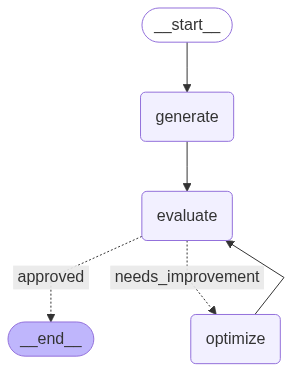

In [12]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

workflow

In [15]:
initial_state = {
    "topic": "srhberhb",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)



In [17]:
result

{'topic': 'srhberhb',
 'tweet': 'My brain trying to spell "strawberry" after 3 coffees vs. my brain trying to spell "srhberhb" after 1 existential crisis. Guess which one is winning. 🍓😵\u200d💫 #srhberhb #brainfail',
 'evaluation': 'approved',
 'feedback': 'The tweet leverages a familiar "my brain vs. my brain" format but injects it with a fresh, humorous, and highly relatable comparison. The contrast between a mundane coffee-induced struggle and a profound existential one is clever, and the invented word "srhberhb" adds a memorable, absurd touch that enhances the humor. It\'s punchy, well-formatted with effective use of emojis and hashtags, and possesses strong viral potential due to its widespread relatability. While the "Guess which one is winning" closing is slightly common, it effectively lands the joke without detracting from the overall impact.',
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['My brain trying to spell "strawberry" after 3 coffees vs. my brain trying to 

# Testing

In [ ]:
# START ----- addon ------ check condition ------- end | addon ---- END

In [72]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

class testState(TypedDict):
    val: int
    target : int
    result : int
    iteration : int
    max_iteration : int
    status : Literal['Yes','No']
    
def initiate(state : testState):
    result = state['val']+1
    #print(state)
    return {'result': result} 

def evaluation(state : testState):
    if state['result'] > state['target'] or state['iteration'] >= state['max_iteration']:
        status = 'Yes'
    else:
        status =  'No'
        
    return {'status': status}

def route_evaluation(state : testState):
    if state['status'] == 'Yes':
        return 'Pass'
    else:
        return 'Fail'
        

def addon(state : testState):
    result = state['result']*2
    iteration = state['iteration']+1
    #print(state)
    return {'result': result, 'iteration': iteration} 

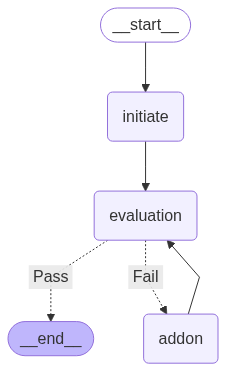

In [73]:
graph = StateGraph(testState)

graph.add_node('initiate',initiate)
graph.add_node('addon',addon)
graph.add_node('evaluation',evaluation)

graph.add_edge(START,'initiate')
graph.add_edge('initiate','evaluation')
graph.add_conditional_edges('evaluation', route_evaluation ,{'Pass': END, 'Fail':'addon'})
graph.add_edge('addon','evaluation')

workflow = graph.compile()
workflow

In [75]:
initate = {
    'val': 0,
    'target' : 10,
    'iteration': 1,
    'max_iteration' : 10
}

workflow.invoke(initate)

{'val': 0,
 'target': 10,
 'result': 16,
 'iteration': 5,
 'max_iteration': 10,
 'status': 'Yes'}